<a href="https://colab.research.google.com/github/Sreekanth3639/DTSC-5082/blob/main/Assignment01_global_literacy_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Loading, Cleaning, and Transformation
## Global Literacy Rates — UNESCO / Wikipedia Dataset


**Topics:** Data Loading · Data Cleaning · Data Transformation  


**Name:** Sreekanth Taduru
**Date:** 03/06/2026  
**Total Points:** 100
         
---

### Background

Literacy is one of the most fundamental indicators of human development. The United Nations Educational, Scientific and Cultural Organization (UNESCO) tracks adult literacy rates across all UN member and observer states. In this assignment, you will work with a real-world dataset sourced directly from Wikipedia's *List of Countries by Literacy Rate* page, which aggregates UNESCO data.

The table you will use is **"List of UN member and observer states by adult literacy rate"**, containing overall literacy rates as well as male and female breakdowns for countries worldwide.

> **Data Source:**  
> Wikipedia — *List of countries by literacy rate*  
> URL: https://en.wikipedia.org/wiki/List_of_countries_by_literacy_rate  
> Data originally from UNESCO Institute for Statistics.

---

### Learning Objectives

By completing this assignment, you will be able to:

1. Load tabular data directly from a web page using `pandas.read_html()`
2. Identify and describe data quality issues in a raw dataset
3. Rename columns for clarity and consistency
4. Handle missing values appropriately
5. Convert columns to correct data types
6. Perform data transformations to create new analytical variables
7. Filter, sort, and summarize data to answer real-world questions

---

### Required Libraries

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

---

## Part 1 — Data Loading (20 points)

### Exercise 1.1 — Load Tables from Wikipedia (5 points)

`pandas.read_html()` can scrape all HTML tables from a webpage and return them as a list of DataFrames.

**Task:** Load all tables from the Wikipedia page below into a list called `tables`.

```
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_literacy_rate'
```

Then print the **number of tables** found and the **shape** of each one.

In [128]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_literacy_rate'
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}


# YOUR CODE HERE
tables = pd.read_html(url, storage_options=headers)


In [129]:
# Print number of tables found
print(f"Number of tables found: {len(tables)}")

Number of tables found: 7


In [130]:
# Print shape of each table
for i, table in enumerate(tables):
    print(f"Table {i} shape: {table.shape}")

Table 0 shape: (234, 9)
Table 1 shape: (196, 6)
Table 2 shape: (10, 7)
Table 3 shape: (13, 2)
Table 4 shape: (2, 2)
Table 5 shape: (6, 2)
Table 6 shape: (13, 2)


### Exercise 1.2 — Identify and Extract the Correct Table (10 points)

Not all tables on the page contain the data we want. We are interested in the table titled **"List of UN member and observer states by adult literacy rate"**, which contains the columns:

- Country
- Literacy rate (all)
- Male literacy
- Female literacy
- Gender difference

**Tasks:**
1. Inspect the first few rows of each table to identify the correct one.
2. Assign the correct table to a variable named `df_raw`.
3. Display the first 10 rows of `df_raw`.

In [131]:
# Inspect tables to find the right one
print("Table 0 Head:")
print(tables[0].head())
print("\nTable 1 Head:")
print(tables[1].head())
print("\nTable 2 Head:")
print(tables[2].head())

Table 0 Head:
            Country Youth (15 to 24)          Adult (25+)          \
            Country             Rate     Year        Rate    Year   
0     Afghanistan *             65.0  2020[4]        31.7 2011.00   
1         Albania *             99.2     2012        97.2 2012.00   
2         Algeria *             93.8     2008        75.1 2008.00   
3  American Samoa *             97.7     1980        97.3 1980.00   
4         Andorra *              NaN      NaN         NaN     NaN   

  Elderly (65+)         Youth Gender Parity Index          
           Rate    Year                      Rate    Year  
0          20.3 2011.00                       0.5 2011.00  
1          86.9 2012.00                       1.0 2012.00  
2          19.5 2008.00                       1.0 2008.00  
3          92.7 1980.00                       1.0 1980.00  
4           NaN     NaN                       NaN     NaN  

Table 1 Head:
         Country Literacy rate[12][13] [text–source integrity?]    

In [132]:
# Assign the correct table to df_raw and display first 10 rows
df_raw = tables[1]

df_raw.head(10)

Country Literacy rate[12][13] [text–source integrity?]  \
                 Country                                          Total   
0          Afghanistan *                                          37.3%   
1              Albania *                                          98.1%   
2              Algeria *                                          81.4%   
3              Andorra *                                         100.0%   
4               Angola *                                          71.1%   
5  Antigua and Barbuda *                                          99.0%   
6            Argentina *                                          99.0%   
7              Armenia *                                          99.8%   
8            Australia *                                          99.0%   
9              Austria *                                          98.0%   

                                    
     Male  Female Gender gap  Year  
0   52.1%   22.6%      29.5%  2021  
1   98.5%   97.8%       0.7%  2018  
2   87.4%   75.3%      12.1%  2018  
3  100.0%  100.0%       0.0%  2016  
4   82.0%   60.7%      21.3%  2015  
5   98.4%   99.4%       1.0%  2015  
6   98.9%   99.1%       0.2%  2018  
7   99.8%   99.7%       0.1%  2020  
8     NaN     NaN        NaN   NaN  
9     NaN     NaN        NaN   NaN

### Exercise 1.3 — Initial Data Inspection (5 points)

Before cleaning, always inspect the raw data carefully.

**Tasks:** Using appropriate pandas methods, report:
1. The shape (number of rows and columns)
2. Column names and data types (`dtypes`)
3. Number of missing values per column
4. Basic descriptive statistics (for numeric columns)

In [133]:
# 1. Shape
# YOUR CODE HERE
print(df_raw.shape)

(196, 6)


In [134]:
# 2. Column names and dtypes
# YOUR CODE HERE
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 6 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   (Country, Country)                                            196 non-null    object
 1   (Literacy rate[12][13] [text–source integrity?], Total)       194 non-null    object
 2   (Literacy rate[12][13] [text–source integrity?], Male)        160 non-null    object
 3   (Literacy rate[12][13] [text–source integrity?], Female)      160 non-null    object
 4   (Literacy rate[12][13] [text–source integrity?], Gender gap)  160 non-null    object
 5   (Literacy rate[12][13] [text–source integrity?], Year)        160 non-null    object
dtypes: object(6)
memory usage: 9.3+ KB
None


In [135]:
# 3. Missing values per column
# YOUR CODE HERE
print(df_raw.isnull().sum())

Country                                         Country        0
Literacy rate[12][13] [text–source integrity?]  Total          2
                                                Male          36
                                                Female        36
                                                Gender gap    36
                                                Year          36
dtype: int64


In [136]:
# 4. Descriptive statistics
# YOUR CODE HERE
print(df_raw.describe())

              Country Literacy rate[12][13] [text–source integrity?]         \
              Country                                          Total   Male   
count             196                                            194    160   
unique            196                                            124    108   
top     Afghanistan *                                          99.0%  99.9%   
freq                1                                             21      8   

                                
       Female Gender gap  Year  
count     160        160   160  
unique    122         92    10  
top     99.7%       0.0%  2018  
freq        8         16    59  


**Question 1.3a:** Based on your inspection, list at least **three data quality issues** you observe (e.g., wrong data types, unexpected characters, missing values, etc.).

*Write your answer here (**double-click to edit**):*

Here are at least three data quality issues observed in the raw data, as requested for Question 1.3a:

**1. Incorrect Data Types:** Many columns, such as 'Literacy rate (all)', 'Male literacy', 'Female literacy', 'Gender difference', and 'Year', are loaded as object (string) type but should ideally be numeric (float or int).

**2. Missing Values:** There are a significant number of missing values across several key columns, particularly in 'Male literacy', 'Female literacy', 'Gender difference', and 'Year', which each have 36 missing values. 'Literacy rate (all)' also has 2 missing values.

**3. Irregular Column Names:** The initial column names are complex MultiIndex with extraneous text and special characters (e.g., ('Literacy rate[12][13] [text–source integrity?]', 'Total')), making them difficult to work with and requiring renaming.

---

## Part 2 — Data Cleaning (35 points)

### Exercise 2.1 — Make a Working Copy and Rename Columns (5 points)

**Tasks:**
1. Create a copy of `df_raw` called `df` so the original remains untouched.
2. Rename the columns to the following standardized names:

| Original column name | New name |
|---|---|
| Country (or territory) | `country` |
| Total | `literacy_all` |
| Male  | `literacy_male` |
| Female | `literacy_female` |
| Gender gap | `gender_diff` |
| Year | `year` |

> **Hint:** Column names may differ slightly depending on how Wikipedia renders the page. Inspect `df_raw.columns` carefully before renaming.

In [138]:
# 1. Make a working copy
# YOUR CODE HERE

df = df_raw.copy()

In [139]:
# 2. Rename columns
# YOUR CODE HERE
# Directly assign new column names to flatten the MultiIndex and rename
df.columns = [
    'country',
    'literacy_all',
    'literacy_male',
    'literacy_female',
    'gender_diff',
    'year'
]

In [140]:
# Verify
print(df.columns.tolist())
df.head()

['country', 'literacy_all', 'literacy_male', 'literacy_female', 'gender_diff', 'year']


,country,literacy_all,literacy_male,literacy_female,gender_diff,year
0,Afghanistan *,37.3%,52.1%,22.6%,29.5%,2021
1,Albania *,98.1%,98.5%,97.8%,0.7%,2018
2,Algeria *,81.4%,87.4%,75.3%,12.1%,2018
3,Andorra *,100.0%,100.0%,100.0%,0.0%,2016
4,Angola *,71.1%,82.0%,60.7%,21.3%,2015


### Exercise 2.2 — Clean the `country` Column (10 points)

Country names on Wikipedia often contain extra characters such as footnote markers (e.g., `[a]`, `[1]`), asterisks (`*`), or leading/trailing whitespace.

**Tasks:**
1. Strip leading and trailing whitespace from `country`.
2. Remove any footnote-style bracketed references like `[a]`, `[1]`, `[note 1]` using a regular expression.
3. Remove any asterisks (`*`) from country names.
4. Print the first 15 country names after cleaning to verify.

In [141]:
# 1. Strip whitespace
# YOUR CODE HERE
df['country'] = df['country'].str.strip()

In [142]:
# 2. Remove bracketed footnote references using regex
# YOUR CODE HERE
df['country'] = df['country'].str.replace(r'\[.*?\]', '', regex=True)

In [143]:
# 3. Remove asterisks
# YOUR CODE HERE
df['country'] = df['country'].str.replace('*', '', regex=False)

In [144]:
# 4. Print first 15 country names
# YOUR CODE HERE
print(df['country'].head(15))

0             Afghanistan 
1                 Albania 
2                 Algeria 
3                 Andorra 
4                  Angola 
5     Antigua and Barbuda 
6               Argentina 
7                 Armenia 
8               Australia 
9                 Austria 
10             Azerbaijan 
11                 Bahamas
12                Bahrain 
13             Bangladesh 
14               Barbados 
Name: country, dtype: object


### Exercise 2.3 — Clean and Convert Numeric Columns (10 points)

The literacy rate columns were read as strings (`object` dtype) and may contain:
- Percent signs (`%`)
- Footnote markers (`[1]`, `[a]`)
- Em dashes or hyphens (`—`, `-`) representing missing data
- Whitespace

**Tasks:** For **each** of the four numeric columns (`literacy_all`, `literacy_male`, `literacy_female`, `gender_diff`):
1. Remove percent signs and any bracketed footnote markers.
2. Replace em dashes (`—`) and plain hyphens used as missing indicators with `np.nan`.
3. Strip whitespace.
4. Convert the column to `float` using `pd.to_numeric()` with `errors='coerce'`.

> **Hint:** It is good practice to write a small cleaning function and apply it to each column rather than repeating code.

In [145]:
def clean_numeric_col(series):
    """
    Clean a pandas Series containing messy numeric strings.
    Returns a float Series.
    """
    # 1. Remove percent signs and any bracketed footnote markers.
    series = series.astype(str).str.replace('%', '', regex=False)
    series = series.str.replace(r'\[.*?\]', '', regex=True)

    # 2. Replace em dashes (—) and plain hyphens used as missing indicators with empty strings.
    series = series.str.replace('—', '', regex=False)
    series = series.str.replace('-', '', regex=False)

    # 3. Strip whitespace.
    series = series.str.strip()

    # 4. Convert the column to float using pd.to_numeric() with errors='coerce'.
    return pd.to_numeric(series, errors='coerce')

# Apply to each numeric column
numeric_cols = ['literacy_all', 'literacy_male', 'literacy_female', 'gender_diff']

for col in numeric_cols:
    df[col] = clean_numeric_col(df[col])

# Verify dtypes
print(df.dtypes)
df.head(10)

country             object
literacy_all       float64
literacy_male      float64
literacy_female    float64
gender_diff        float64
year                object
dtype: object


,country,literacy_all,literacy_male,literacy_female,gender_diff,year
0,Afghanistan,37.30,52.10,22.60,29.50,2021
1,Albania,98.10,98.50,97.80,0.70,2018
2,Algeria,81.40,87.40,75.30,12.10,2018
3,Andorra,100.00,100.00,100.00,0.00,2016
4,Angola,71.10,82.00,60.70,21.30,2015
5,Antigua and Barbuda,99.00,98.40,99.40,1.00,2015
6,Argentina,99.00,98.90,99.10,0.20,2018
7,Armenia,99.80,99.80,99.70,0.10,2020
8,Australia,99.00,NaN,NaN,NaN,NaN
9,Austria,98.00,NaN,NaN,NaN,NaN


### Exercise 2.4 — Handle Missing Values (10 points)

**Tasks:**
1. Report the count and percentage of missing values for each column after cleaning.
2. Drop rows where `literacy_all` is missing, since this is our primary variable. Save the result back to `df`.
3. For `literacy_male` and `literacy_female`, do **not** drop rows — we will keep them as `NaN`. Briefly explain why this is a better strategy than dropping.
4. Reset the DataFrame index after dropping rows.

In [146]:
# 1. Missing value report
def missing_val_analysis(df):
    missing_count = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing Percentage (%)': missing_percentage
    })
    print(missing_df)

missing_val_analysis(df)

                 Missing Count  Missing Percentage (%)
country                      0                    0.00
literacy_all                 2                    1.02
literacy_male               36                   18.37
literacy_female             36                   18.37
gender_diff                 36                   18.37
year                        36                   18.37


In [147]:
# 2. Drop rows where literacy_all is missing
# YOUR CODE HERE
df.dropna(subset=['literacy_all'], inplace=True)

In [148]:
# 3. Reset index
# YOUR CODE HERE
df.reset_index(drop=True, inplace=True)

print(f'Rows remaining: {len(df)}')


Rows remaining: 194


**Question 2.4:** Why is it better to keep `NaN` for missing male/female literacy values rather than dropping those rows?

*Write your answer here: (**double click to edit**):*

Keeping NaN for missing male/female literacy is better because it prevents data loss, avoids potential analysis bias from dropping rows, and allows for future imputation if needed, while still retaining valuable overall literacy information for those countries.

---

## Part 3 — Data Transformation (30 points)

### Exercise 3.1 — Categorize Countries by Literacy Level (10 points)

Create a new column called `literacy_category` that classifies countries based on their overall literacy rate (`literacy_all`) using the following thresholds:

| Category | Condition |
|---|---|
| `'Very High'` | literacy_all ≥ 95% |
| `'High'` | 80% ≤ literacy_all < 95% |
| `'Medium'` | 60% ≤ literacy_all < 80% |
| `'Low'` | literacy_all < 60% |

**Tasks:**
1. Create the `literacy_category` column using `pd.cut()`.
2. Print the value counts for each category.
3. Print the percentage of countries in each category (rounded to 1 decimal place).

In [149]:
# 1. Create literacy_category column
# YOUR CODE HERE
bins = [0, 60, 80, 95, 100.00001] # Adjusted upper bound to include 100%
labels = ['Low', 'Medium', 'High', 'Very High']
df['literacy_category'] = pd.cut(df['literacy_all'], bins=bins, labels=labels, right=False, include_lowest=True)

In [150]:
# 2. Value counts
# YOUR CODE HERE
print(df['literacy_category'].value_counts())

literacy_category
Very High    105
High          43
Medium        27
Low           19
Name: count, dtype: int64


In [151]:
# 3. Percentage
# YOUR CODE HERE
print(df['literacy_category'].value_counts(normalize=True).mul(100).round(1))

literacy_category
Very High   54.10
High        22.20
Medium      13.90
Low          9.80
Name: proportion, dtype: float64


### Exercise 3.2 — Compute Gender Gap Indicator (10 points)

**Tasks:**
1. For rows where both `literacy_male` and `literacy_female` are available, verify that `gender_diff` equals `literacy_male − literacy_female`. Report how many rows match and how many do not (due to rounding, allow a tolerance of ±0.2).

2. Create a new column `gender_gap_direction` with values:
   - `'Male advantage'` if `gender_diff > 0.5`
   - `'Female advantage'` if `gender_diff < -0.5`
   - `'Near parity'` if `|gender_diff| <= 0.5`
   - `NaN` where `gender_diff` is missing

3. Report the count of countries in each direction category.

In [152]:
# 1. Verify gender_diff calculation
# YOUR CODE HERE
# Calculate the difference based on male and female literacy rates
calculated_gender_diff = df['literacy_male'] - df['literacy_female']

# Compare with existing gender_diff, allowing for a small tolerance for rounding issues
tolerance = 0.2
matches = (abs(df['gender_diff'] - calculated_gender_diff) <= tolerance)

# Count how many match and how many do not
num_matches = matches.sum()
num_non_matches = (~matches & df['gender_diff'].notna() & calculated_gender_diff.notna()).sum()

print(f"Number of rows where gender_diff matches (within +/- {tolerance}): {num_matches}")
print(f"Number of rows where gender_diff does not match (within +/- {tolerance}): {num_non_matches}")

Number of rows where gender_diff matches (within +/- 0.2): 139
Number of rows where gender_diff does not match (within +/- 0.2): 21


In [153]:
# 2. Create gender_gap_direction column
# YOUR CODE HERE
conditions = [
    df['gender_diff'] > 0.5,
    df['gender_diff'] < -0.5,
    abs(df['gender_diff']) <= 0.5
]
choices = ['Male advantage', 'Female advantage', 'Near parity']
df['gender_gap_direction'] = np.select(conditions, choices, default=None)


In [154]:
# 3. Count by direction
# YOUR CODE HERE
print(df['gender_gap_direction'].value_counts(dropna=False))

gender_gap_direction
Male advantage    115
Near parity        45
None               34
Name: count, dtype: int64


### Exercise 3.3 — Sorting and Ranking (5 points)

**Tasks:**
1. Add a column `rank` that ranks countries from highest to lowest overall literacy rate (rank 1 = highest). Use `df['literacy_all'].rank(ascending=False, method='min')`.
2. Display the **top 10** and **bottom 10** countries by literacy rate, showing `country`, `literacy_all`, `literacy_category`, and `rank`.

In [155]:
# 1. Create rank column
# YOUR CODE HERE
df['rank'] = df['literacy_all'].rank(ascending=False, method='min')

In [156]:
# 2. Top 10
print('=== Top 10 Countries by Literacy Rate ===')
# YOUR CODE HERE
print(df.sort_values('rank').head(10)[['country', 'literacy_all', 'literacy_category', 'rank']])

=== Top 10 Countries by Literacy Rate ===
            country  literacy_all literacy_category  rank
3          Andorra         100.00         Very High  1.00
57         Finland         100.00         Very High  1.00
126         Norway         100.00         Very High  1.00
86     North Korea         100.00         Very High  1.00
96   Liechtenstein         100.00         Very High  1.00
98      Luxembourg         100.00         Very High  1.00
186     Uzbekistan         100.00         Very High  1.00
154       Slovakia         100.00         Very High  1.00
15         Belarus          99.90         Very High  9.00
146     San Marino          99.90         Very High  9.00


In [157]:
# Bottom 10
print('\n=== Bottom 10 Countries by Literacy Rate ===')
# YOUR CODE HERE
print(df.sort_values('rank', ascending=False).head(10)[['country', 'literacy_all', 'literacy_category', 'rank']])


=== Bottom 10 Countries by Literacy Rate ===
                       country  literacy_all literacy_category   rank
33                       Chad          22.30               Low 194.00
159               South Sudan          34.50               Low 193.00
123                     Niger          35.10               Low 192.00
103                      Mali          35.50               Low 191.00
0                 Afghanistan          37.30               Low 190.00
32   Central African Republic          37.40               Low 189.00
157                   Somalia          39.00               Low 188.00
26               Burkina Faso          39.30               Low 187.00
67                     Guinea          39.60               Low 186.00
18                      Benin          42.40               Low 185.00


### Exercise 3.4 — Group-Level Summary Statistics (5 points)

**Tasks:** Using `groupby`, compute the following for each `literacy_category`:
- Number of countries
- Mean overall literacy rate
- Mean male literacy rate
- Mean female literacy rate
- Mean gender difference

Round all means to 2 decimal places and sort from highest to lowest literacy category.

In [158]:
# Group-level summary
# YOUR CODE HERE
summary_stats = df.groupby('literacy_category', observed=False).agg(
    num_countries=('country', 'count'),
    mean_literacy_all=('literacy_all', 'mean'),
    mean_literacy_male=('literacy_male', 'mean'),
    mean_literacy_female=('literacy_female', 'mean'),
    mean_gender_diff=('gender_diff', 'mean')
).round(2).sort_values(by='mean_literacy_all', ascending=False)

print(summary_stats)

                   num_countries  mean_literacy_all  mean_literacy_male  \
literacy_category                                                         
Very High                    105              98.35               98.67   
High                          43              88.44               90.77   
Medium                        27              70.91               77.26   
Low                           19              44.14               54.89   

                   mean_literacy_female  mean_gender_diff  
literacy_category                                          
Very High                         97.74              1.08  
High                              86.20              5.54  
Medium                            64.44             14.22  
Low                               34.69             20.21  


---

## Part 4 — Analysis Questions (15 points)

Use the cleaned `df` to answer the following questions with code and a one-sentence written interpretation.

### Question 4.1 (5 points)
Which countries have a **female literacy rate higher than the male literacy rate** (i.e., `gender_diff < 0`)? List them sorted by `gender_diff` ascending (largest female advantage first), showing `country`, `literacy_all`, `literacy_male`, `literacy_female`, and `gender_diff`.

In [159]:
# YOUR CODE HERE
female_advantage_countries = df[df['gender_diff'] < 0]

print(female_advantage_countries.sort_values(by='gender_diff', ascending=True)[['country', 'literacy_all', 'literacy_male', 'literacy_female', 'gender_diff']])

Empty DataFrame
Columns: [country, literacy_all, literacy_male, literacy_female, gender_diff]
Index: []


*Interpretation:*
This means that, based on the provided dataset and the definition of gender_diff (male literacy rate - female literacy rate), there are no countries in this dataset where the female literacy rate is explicitly higher than the male literacy rate (i.e., gender_diff is less than 0).


### Question 4.2 (5 points)
What is the **global average** literacy rate (mean of `literacy_all`)? How does it compare to the average for countries in the `'Low'` and `'Very High'` categories?

In [160]:
# YOUR CODE HERE
global_avg_literacy = df['literacy_all'].mean()
print(f"Global average literacy rate: {global_avg_literacy:.2f}%")

low_literacy_avg = summary_stats.loc['Low', 'mean_literacy_all']
very_high_literacy_avg = summary_stats.loc['Very High', 'mean_literacy_all']

print(f"Average literacy rate for 'Low' category: {low_literacy_avg:.2f}%")
print(f"Average literacy rate for 'Very High' category: {very_high_literacy_avg:.2f}%")

Global average literacy rate: 87.03%
Average literacy rate for 'Low' category: 44.14%
Average literacy rate for 'Very High' category: 98.35%


**Interpretation: (Double click to edit):**

The global average literacy rate of 87.03% is significantly higher than the average for countries in the 'Low' category (44.14%), indicating a wide disparity in educational attainment worldwide. Conversely, it is considerably lower than the average for countries in the 'Very High' category (98.35%), suggesting that a large portion of the world's population still falls below the highest literacy standards.


### Question 4.3 (5 points)
Create a **horizontal bar chart** showing the 15 countries with the lowest overall literacy rate. Use `matplotlib`. Label the axes, add a title, and use a color that highlights the bars.

> **Hint:** Sort the data appropriately so the country with the lowest rate appears at the bottom of the chart.

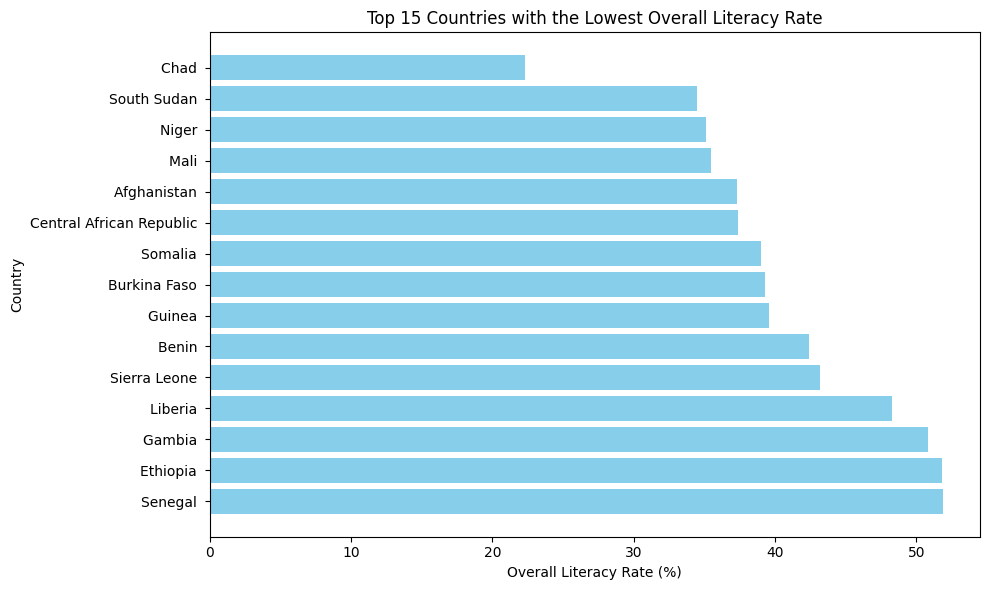

In [161]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10, 6))  # feel free to modify

# Sort by literacy_all in ascending order and get the bottom 15
lowest_literacy_countries = df.sort_values(by='literacy_all', ascending=True).head(15)

# For horizontal bar chart, we want the lowest value at the bottom, so reverse the order for plotting
lowest_literacy_countries = lowest_literacy_countries.sort_values(by='literacy_all', ascending=False)

ax.barh(lowest_literacy_countries['country'], lowest_literacy_countries['literacy_all'], color='skyblue')

# Label the axes and add a title
ax.set_xlabel('Overall Literacy Rate (%)')
ax.set_ylabel('Country')
ax.set_title('Top 15 Countries with the Lowest Overall Literacy Rate')

# Ensure layout is tight
plt.tight_layout()
plt.show()

---

## Part 5 — Export (Bonus, 5 points)

Save the fully cleaned and transformed `df` to a CSV file called `literacy_rates_clean.csv` with the index reset (no index column saved).

In [162]:
# YOUR CODE HERE
df.to_csv('literacy_rates_clean.csv', index=False)

---

## Submission Checklist

Before submitting, make sure you have:

- [ ] Run all cells from top to bottom without errors (Kernel → Restart & Run All)
- [ ] Written interpretations for all open-ended questions
- [ ] Saved the notebook with all output visible
